<a href="https://colab.research.google.com/github/hassanatif992-hash/urdu-ocr-codesaviours-si26-MuhammadHassaan/blob/main/SI26_Week2_MuhammadHassaan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 – Urdu OCR Image Preprocessing and OCR Testing

Name: Muhammad Hassaan  
Batch: SI-26  
Project: Urdu OCR  

## Objective
This notebook preprocesses Urdu OCR images using OpenCV and tests Tesseract OCR on Urdu text.

In [ ]:
!pip install opencv-python-headless pillow pytesseract

import cv2
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt
import pytesseract

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
folders = [
    "data/raw/books",
    "data/raw/newspaper",
    "data/raw/signboards",
    "data/raw/synthetic",
    "data/raw/other",
    "data/processed"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [ ]:
def preprocess_image(image_path, save_path):
    img = cv2.imread(image_path)

    if img is None:
        print("Could not load:", image_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    scale = 600 / w
    resized = cv2.resize(gray, (int(w * scale), int(h * scale)))

    denoised = cv2.GaussianBlur(resized, (5, 5), 0)

    binary = cv2.adaptiveThreshold(
        denoised,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    cv2.imwrite(save_path, binary)
    return binary

print("Preprocessing function ready!")

Preprocessing function ready!


In [ ]:
all_images = []
for ext in ["png", "PNG", "jpg", "jpeg", "JPG", "JPEG"]:
    all_images += glob.glob(f"data/raw/**/*.{ext}", recursive=True)

print("Total raw images:", len(all_images))

processed_count = 0

for img_path in all_images:
    category = img_path.split("/")[-2]
    filename = os.path.basename(img_path)

    save_dir = f"data/processed/{category}"
    os.makedirs(save_dir, exist_ok=True)

    save_path = f"{save_dir}/{filename}"

    result = preprocess_image(img_path, save_path)

    if result is not None:
        processed_count += 1

print("Processed images:", processed_count)

Total raw images: 101
Processed images: 101


In [ ]:
processed_images = []
for ext in ["png", "PNG", "jpg", "jpeg", "JPG", "JPEG"]:
    processed_images += glob.glob(f"data/processed/**/*.{ext}", recursive=True)

print("Total processed images:", len(processed_images))

Total processed images: 101


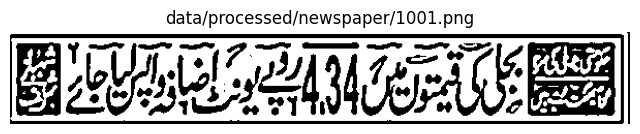

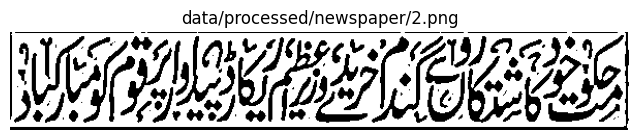

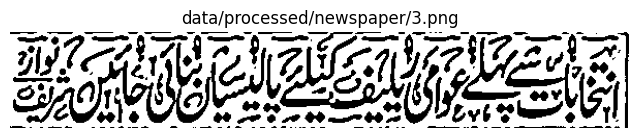

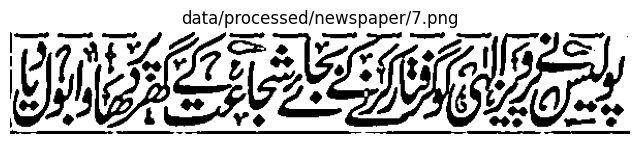

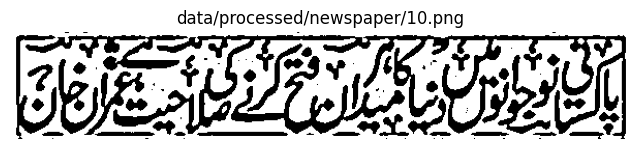

In [ ]:
for img_path in processed_images[:5]:
    img = Image.open(img_path)

    plt.figure(figsize=(8, 3))
    plt.imshow(img, cmap="gray")
    plt.title(img_path)
    plt.axis("off")
    plt.show()

In [ ]:
!apt-get install -y tesseract-ocr tesseract-ocr-urd
!pip install pytesseract

print("Tesseract installed successfully!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-urd is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Tesseract installed successfully!


In [ ]:
print("=== Tesseract OCR Results ===")

for img_path in processed_images[:5]:
    img = Image.open(img_path)
    text = pytesseract.image_to_string(img, lang="urd")

    print("Image:", img_path)
    print("OCR Output:")
    print(text)
    print("-" * 50)

=== Tesseract OCR Results ===
Image: data/processed/newspaper/1001.png
OCR Output:
 

--------------------------------------------------
Image: data/processed/newspaper/2.png
OCR Output:
 

 

--------------------------------------------------
Image: data/processed/newspaper/3.png
OCR Output:
 

را را ای ا شا ر1
ےا ] ا و نے

--------------------------------------------------
Image: data/processed/newspaper/7.png
OCR Output:
ا ات نے ےنا

--------------------------------------------------
Image: data/processed/newspaper/10.png
OCR Output:
 

--------------------------------------------------


# Gap Analysis

## Observations

- Tesseract OCR produced incorrect results for several Urdu images.
- Some images returned empty text.
- Some Urdu characters were recognized incorrectly.
- Connected Urdu letters were broken into separate characters.
- Words were incomplete or missing.

## Why Tesseract Fails on Urdu

Urdu is a cursive language where letters are connected. The shape of each letter changes depending on its position in a word. Urdu also contains dots and complex ligatures, making recognition difficult for general OCR engines like Tesseract.

## Conclusion

The OCR results show that Tesseract has limited accuracy for Urdu text recognition. A dedicated Urdu OCR model trained on Urdu datasets is required to achieve better performance.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!zip -r processed.zip data/processed

# Week 2 – Day 4: Dataset Verification

## Objective
Verify raw and processed dataset folders and confirm that all images are organized correctly.

In [39]:
import os
import glob
import pandas as pd

categories = ["books", "newspaper", "signboards", "synthetic", "other"]

print("Raw Dataset Count:")
for category in categories:
    files = glob.glob(f"data/raw/{category}/*")
    print(category, ":", len(files))

print("\nProcessed Dataset Count:")
for category in categories:
    files = glob.glob(f"data/processed/{category}/*")
    print(category, ":", len(files))

Raw Dataset Count:
books : 22
newspaper : 20
signboards : 18
synthetic : 20
other : 21

Processed Dataset Count:
books : 22
newspaper : 20
signboards : 18
synthetic : 20
other : 21


In [40]:
dataset_info = []

for category in categories:
    raw_files = glob.glob(f"data/raw/{category}/*")
    processed_files = glob.glob(f"data/processed/{category}/*")

    dataset_info.append({
        "category": category,
        "raw_images": len(raw_files),
        "processed_images": len(processed_files)
    })

df_summary = pd.DataFrame(dataset_info)
df_summary

,category,raw_images,processed_images
0,books,22,22
1,newspaper,20,20
2,signboards,18,18
3,synthetic,20,20
4,other,21,21


In [41]:
df_summary.to_csv("week2_dataset_summary.csv", index=False)

print("week2_dataset_summary.csv created successfully!")

week2_dataset_summary.csv created successfully!


In [42]:
import os

required_paths = [
    "data/raw",
    "data/processed",
    "week2_dataset_summary.csv"
]

for path in required_paths:
    if os.path.exists(path):
        print(path, "exists")
    else:
        print(path, "missing")

data/raw exists
data/processed exists
week2_dataset_summary.csv exists


## Final Week 2 Summary

During Week 2, Urdu OCR images were preprocessed using OpenCV. The preprocessing steps included grayscale conversion, resizing, noise reduction, and adaptive thresholding. Tesseract OCR was tested on the processed Urdu images, but the results showed low accuracy due to the complexity of Urdu script.

The dataset was verified by comparing raw and processed image counts. All categories were successfully processed and organized in the required folder structure.

## Final Conclusion

Tesseract OCR is not fully reliable for Urdu text recognition. Urdu cursive writing, connected letters, dots, and complex ligatures make OCR challenging. This confirms the need for a custom Urdu OCR model.